file ground-truth.xml telah dibuat. total 33 bounding box.


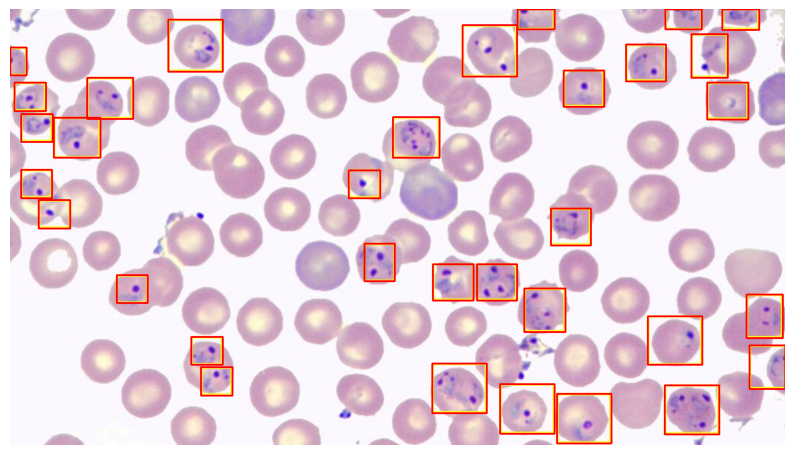

In [25]:
import os
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load gambar ground-truth
img_path = (  
    "ground-truth.jpeg"
)
img = cv2.imread(img_path)
h, w, _ = img.shape

# deteksi warna kuning dari kotak
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower_yellow = np.array([15, 80, 80])
upper_yellow = np.array([40, 255, 255])
mask = cv2.inRange(hsv, lower_yellow, upper_yellow)

inv_mask = cv2.bitwise_not(mask)
ff_mask = inv_mask.copy()
cv2.floodFill(ff_mask, None, (0, 0), 0)
cv2.floodFill(ff_mask, None, (w - 1, 0), 0)
cv2.floodFill(ff_mask, None, (0, h - 1), 0)
cv2.floodFill(ff_mask, None, (w - 1, h - 1), 0)

# cari kontur dari kotak kuning
contours, _ = cv2.findContours(
    ff_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

# buat XML
annotation = ET.Element("annotation")
ET.SubElement(annotation, "folder").text = "data_input"
ET.SubElement(annotation, "filename").text = (
    "raw.jpeg"
)
ET.SubElement(annotation, "path").text = "raw.jpeg"

source = ET.SubElement(annotation, "source")
ET.SubElement(source, "database").text = "Unknown"

size = ET.SubElement(annotation, "size")
ET.SubElement(size, "width").text = str(w)
ET.SubElement(size, "height").text = str(h)
ET.SubElement(size, "depth").text = "3"

ET.SubElement(annotation, "segmented").text = "0"

# mengambil koordinat bndbox
count = 0
for cnt in contours:
  x, y, bw, bh = cv2.boundingRect(cnt)
  if bw > 12 and bh > 12:
    xmin = max(0, x - 3)
    ymin = max(0, y - 3)
    xmax = min(w, x + bw + 3)
    ymax = min(h, y + bh + 3)

    obj = ET.SubElement(annotation, "object")
    ET.SubElement(obj, "name").text = "cell"
    ET.SubElement(obj, "pose").text = "Unspecified"
    ET.SubElement(obj, "truncated").text = "0"
    ET.SubElement(obj, "difficult").text = "0"

    bndbox = ET.SubElement(obj, "bndbox")
    ET.SubElement(bndbox, "xmin").text = str(xmin)
    ET.SubElement(bndbox, "ymin").text = str(ymin)
    ET.SubElement(bndbox, "xmax").text = str(xmax)
    ET.SubElement(bndbox, "ymax").text = str(ymax)

    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 0, 255), 2)
    count += 1

# simpan file XML
tree = ET.ElementTree(annotation)
xml_output_path = "ground-truth.xml"
tree.write(xml_output_path)

print(
    f"file {xml_output_path} telah dibuat. total {count}"
    " bounding box."
)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

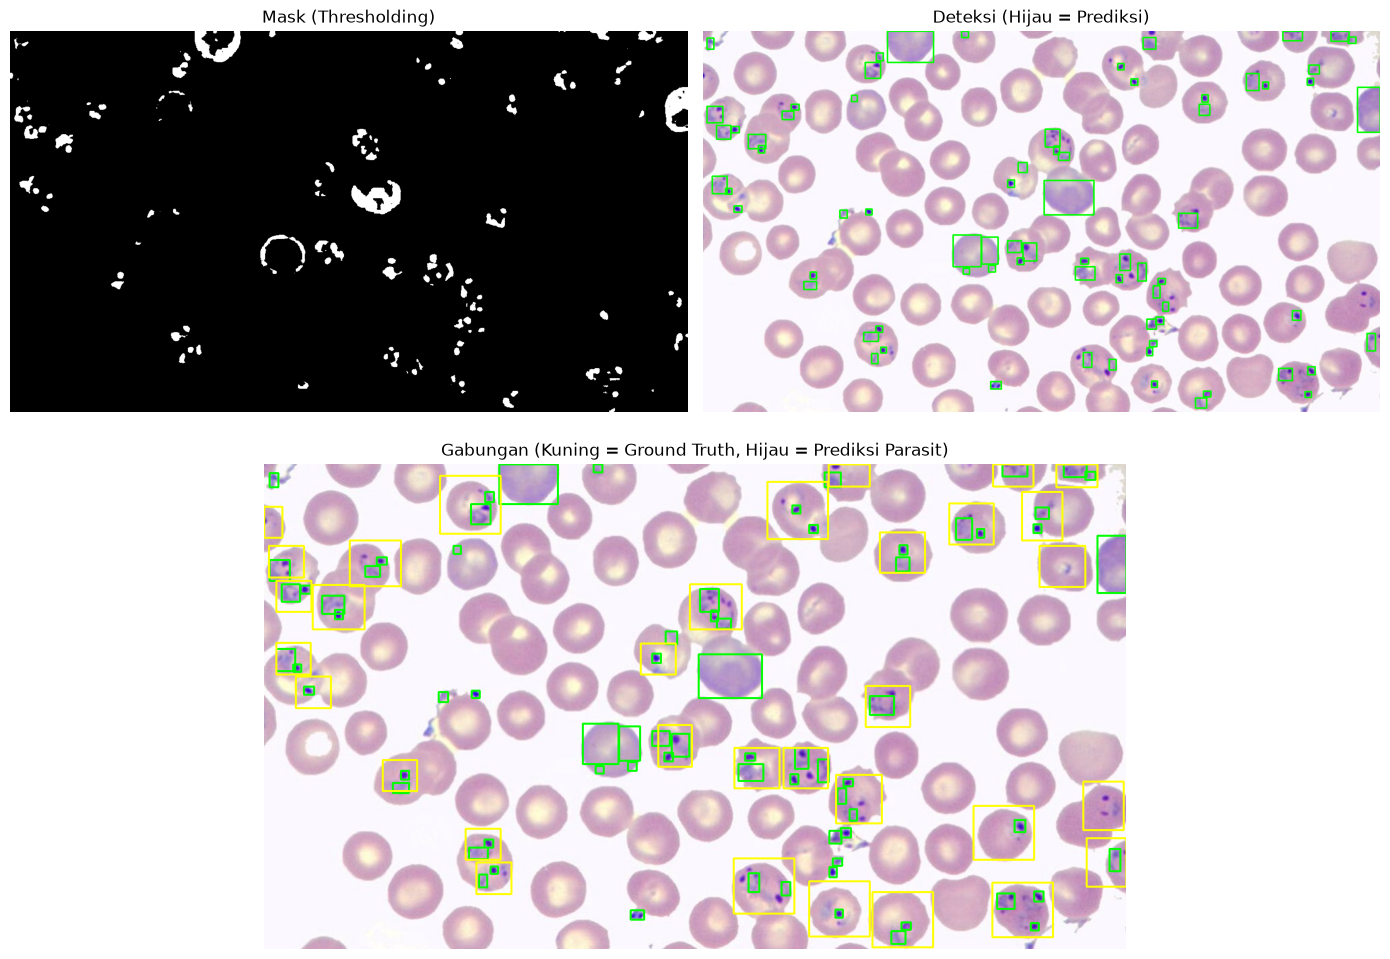

Evaluasi Deteksi:
True Positive: 30
False Positive: 44
False Negative: 3
Precision: 0.405
Recall: 0.909
F1-Score: 0.561


In [ ]:
import os
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Nama file (pastikan ada ground_truth.png dan ground_truth.xml di folder tsb)
img_name = "raw.jpeg"
xml_name = "ground-truth.xml"
img_path = os.path.join(img_name)
xml_path = os.path.join(xml_name)

# ==== 2. Load Image ====
img_raw = cv2.imread(img_path)

# Salinan gambar untuk visualisasi terpisah dan gabungan
img_pred = img_raw.copy()
img_gt = img_raw.copy()
img_combined = img_raw.copy()

# ==== 3. Deteksi warna ungu pakai thresholding (HSV) ====
hsv = cv2.cvtColor(img_raw, cv2.COLOR_BGR2HSV)

# Rentang warna ungu (silakan sesuaikan jika kurang pas)
lower_purple = np.array([125, 50, 50])
upper_purple = np.array([140, 255, 255])

mask = cv2.inRange(hsv, lower_purple, upper_purple)

# Cari kontur hasil threshold
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
pred_bboxes = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w > 10 and h > 10:  # filter noise
        pred_bboxes.append((x, y, x+w, y+h))
        # Gambar prediksi (Hijau)
        cv2.rectangle(img_pred, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.rectangle(img_combined, (x, y), (x+w, y+h), (0, 255, 0), 2)

# ==== 4. Load Ground Truth dari XML (Pascal VOC) ====
def parse_voc_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    bboxes = []
    for obj in root.findall("object"):
        bndbox = obj.find("bndbox")
        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)
        bboxes.append((xmin, ymin, xmax, ymax))
    return bboxes

gt_bboxes = parse_voc_xml(xml_path)

# Gambar Ground Truth (Kuning) pada img_gt dan img_combined
for box in gt_bboxes:
    cv2.rectangle(img_gt, (box[0], box[1]), (box[2], box[3]), (0, 255, 255), 2)        # Kuning: GT
    cv2.rectangle(img_combined, (box[0], box[1]), (box[2], box[3]), (0, 255, 255), 2)  # Kuning: GT

# ==== 5. Evaluasi Precision & Recall (IoU + Centroid) ====
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    boxBArea = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

def is_center_inside(pred, gt):
    cx = (pred[0] + pred[2]) // 2
    cy = (pred[1] + pred[3]) // 2
    return gt[0] <= cx <= gt[2] and gt[1] <= cy <= gt[3]

TP = 0
FP = 0
FN = 0

matched_gt = set()
iou_thresh = 0.2  # lebih toleran untuk objek kecil

for pred in pred_bboxes:
    found_match = False
    for i, gt in enumerate(gt_bboxes):
        if i in matched_gt:
            continue
        if iou(pred, gt) > iou_thresh or is_center_inside(pred, gt):
            TP += 1
            matched_gt.add(i)
            found_match = True
            break
    if not found_match:
        FP += 1

FN = len(gt_bboxes) - TP

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

# ==== 6. Tampilkan Hasil Visualisasi ====
fig = plt.figure(figsize=(14, 10))

ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.imshow(mask, cmap="gray")
ax1.set_title("Mask (Thresholding)")
ax1.axis("off")

ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.imshow(cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB))
ax2.set_title("Deteksi (Hijau = Prediksi)")
ax2.axis("off")

ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
ax3.imshow(cv2.cvtColor(img_combined, cv2.COLOR_BGR2RGB))
ax3.set_title("Gabungan (Kuning = Ground Truth, Hijau = Prediksi Parasit)")
ax3.axis("off")

plt.tight_layout()
plt.show()

print("Evaluasi Deteksi:")
print(f"True Positive: {TP}")
print(f"False Positive: {FP}")
print(f"False Negative: {FN}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")